# AGC ttbar — local facility

Runs the [AGC CMS open-data ttbar analysis](https://github.com/iris-hep/analysis-grand-challenge) through `coffea-workflow` on your own machine: `facilities.local` + `FuturesExecutor`. No cluster, no setup — this is the debug loop before moving to coffea-casa or lxplus.

The analysis code lives in [`ttbar_analysis.py`](ttbar_analysis.py) as three plain functions (`get_fileset`, `run_analysis`, `plotting_1`). Nothing in this notebook changes it — everything about *where and how* to run lives in `RunConfig`.

In [1]:
import sys

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run
from coffea_workflow import facilities
from ttbar_analysis import get_fileset, run_analysis, plotting_1

## Build the workflow

Map each function to a typed step and wire the DAG. This block is identical in every notebook of this repo — only the `RunConfig` below differs.

Analysis knobs travel as `builder_params` — they are part of each artifact's identity, so changing a value here (say `n_files_max_per_sample`) automatically invalidates exactly the caches it affects.

In [2]:
step_fileset = Step(
    name="Fileset_ttbar",
    step_type=Fileset,
    builder=get_fileset,
    builder_params={"with_failure": True,
                    "n_files_max_per_sample": 2},  # -1 for the full AGC
    output="fileset_dict",
)
step_analysis = Step(
    name="Analysis_ttbar",
    step_type=Analysis,
    builder=run_analysis,
    builder_params={"use_inference": False},       # ML inference needs xgboost + models/
    input="fileset_dict",
    output="analysis_payload",
)
step_plotting = Step(
    name="Plot_ttbar",
    step_type=Plotting,
    builder=plotting_1,
    input="analysis_payload",
)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

Step(name='Plot_ttbar', step_type=<class 'coffea_workflow.artifacts.Plotting'>, builder=<function plotting_1 at 0x7efa2ef86200>, builder_params=None, facility=None, executor_config=None, input='analysis_payload', output=None)

## Quick sanity check on one dataset

`datasets=[...]` restricts the run to named datasets — the fastest way to validate the pipeline before processing everything. `single_top_s_chan__nominal` is the smallest AGC dataset (~770k events at 2 files/sample). `strategy="by_dataset"` gives one independently cached chunk per dataset.

Workflow DAG:
  [0] Fileset_ttbar -> Fileset builder=<function get_fileset at 0x7efa303772e0>
  [1] Analysis_ttbar -> Analysis builder=<function run_analysis at 0x7efa2f971b20>
  [2] Plot_ttbar -> Plotting builder=<function plotting_1 at 0x7efa2ef86200>
Edges:
  Fileset_ttbar -> Analysis_ttbar
  Analysis_ttbar -> Plot_ttbar

Run config:
  Strategy:  by_dataset
  Executor:  FuturesExecutor  workers=None
  Facility:  LocalFactory  (workers=4)

Executing step 'Fileset_ttbar' of type 'Fileset' with the user code <function get_fileset at 0x7efa303772e0> and user parameters {'with_failure': True, 'n_files_max_per_sample': 2}
processes in fileset: ['ttbar__nominal', 'ttbar__scaledown', 'ttbar__scaleup', 'ttbar__ME_var', 'ttbar__PS_var', 'single_top_s_chan__nominal', 'single_top_t_chan__nominal', 'single_top_tW__nominal', 'wjets__nominal']

example of information in fileset:
['root://eeeeexrootd-local.unl.edu:1094//store/user/AGC/nanoAOD/ST_s-channel_4f_InclusiveDecays_13TeV-amcatnlo-pythia8/c

Output()

Output()


execution took 7.28 seconds
Successfully processed!
------------------------------------
Processing fileset_chunk_1.json


Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 154, in open
    file = ReadOnlyFile(
           ^^^^^^


execution took 1.22 seconds
Failure caught!
  -> materialized at .cache_local_failed/Analysis/b1656d720bf690b9ac0818fef577ff7aa40a0e025b26a6b15ba93332e155ee4e

Executing step 'Plot_ttbar' of type 'Plotting' with the user code <function plotting_1 at 0x7efa2ef86200> and user parameters None
dict_keys(['builder', 'n_chunks_total', 'n_chunks_ok', 'failures', 'processor_result'])
  -> materialized at .cache_local_failed/Plotting/b3f8bda676c6b0a5b7638c95d070cdd346bbef4973b2ceccba0ae127aaac4dd8


=== Run Summary ===
  ✓  Fileset_ttbar                  Fileset
  !  Analysis_ttbar                 Analysis             1/2 chunks OK
       FAILED fileset_chunk_1.json: Err(OSError('XRootD error: [FATAL] Invalid address'))
  ✓  Plot_ttbar                     Plotting



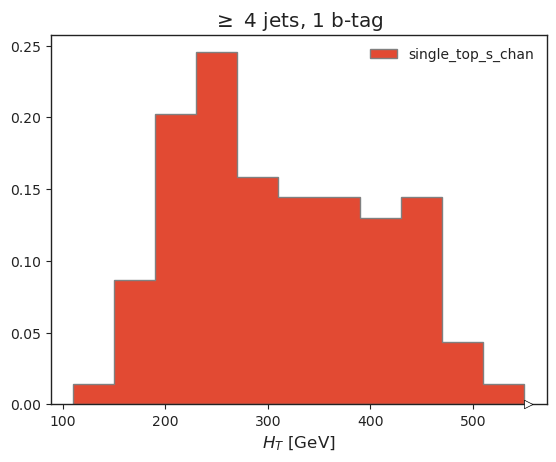

In [3]:
config = RunConfig(
    strategy="by_dataset",
    percentage=25,
    datasets=["single_top_s_chan__nominal"],   # smallest dataset, for a fast check
    cache_dir=".cache_local_failed",
    facility=facilities.local,
    executor_config=ExecutorConfig(executor_type="FuturesExecutor"),
)

result = run(workflow, config)